# Tutorial 5: compute and efficiency
**Deep Learning 89-6877, Fall 2026.** TA: Tal Fiskus.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/idansc/dl-course-2026/blob/main/tutorials/T05_compute_efficiency.ipynb)
Recap slides: [T05_compute_efficiency_recap.pdf](https://github.com/idansc/dl-course-2026/blob/main/tutorials/recap/T05_compute_efficiency_recap.pdf)

Plan for today (≈ 60 min):
1. Lecture recap: quantization, pruning, distillation, KV cache, FlashAttention, speculative decoding (10 min)
2. From earlier tutorials: a char mini-GPT and a small CNN, trained here (run while we talk)
3. Resource accounting: parameters, FLOPs, memory, MFU (10 min)
4. KV cache: identical tokens, fewer FLOPs (8 min)
5. Quantization by hand: per-channel int8 and int4, loss vs bits (8 min)
6. Magnitude pruning, unstructured and channel-level (8 min)
7. Knowledge distillation (6 min)
8. bf16 autocast, `torch.compile`, profiling (4 min)
9. Why decoding is memory-bound: tokens/s vs batch size and a roofline (6 min)
10. If time: speculative decoding with a 4-bit draft

Runs on CPU (Colab or laptop) in a few minutes. Cells marked ✏️ are for you to try.

In [1]:
import copy, math, time
from contextlib import nullcontext
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
bench = "cpu"      # device for the KV-cache timing and the profiler (sections 4 and 8); section 9 uses `device`
print("device:", device, "| bench:", bench, "| threads:", torch.get_num_threads())

def sync(dev):
    if dev == "cuda": torch.cuda.synchronize()
    if dev == "mps": torch.mps.synchronize()

def time_fn(fn, dev, reps=10):              # ms per call (best of reps)
    fn(); fn(); sync(dev)                      # warm-up (and compilation, for torch.compile)
    best = float("inf")
    for _ in range(reps):                      # min over repeats: robust to other processes on the machine
        t0 = time.time(); fn(); sync(dev); best = min(best, time.time() - t0)
    return best * 1e3

device: mps | bench: cpu | threads: 2


## 1. Lecture recap

**Compute.** A dense transformer with $N$ weights costs $\approx 2N$ FLOPs per token forward and $\approx 6N$ per token in training; training with Adam holds $\approx 16$ bytes/param of state. Achieved FLOP/s over peak FLOP/s is the MFU.

**Why efficiency.** A 70B model is 140 GB in bf16. Decoding one token re-reads every weight, so at small batch
$\text{tokens/s} \approx \text{memory bandwidth} / \text{model bytes}$. The levers: fewer bits, fewer weights, fewer recomputed FLOPs.

**Linear quantization.** $r = S(q - Z)$ with integer $q$. Symmetric ($Z=0$), $b$ bits:
$$S = \frac{\max|r|}{2^{b-1}-1},\qquad q = \mathrm{clamp}\big(\mathrm{round}(r/S),\,-(2^{b-1}-1),\,2^{b-1}-1\big),\qquad \hat r = S\,q .$$
**Per-channel**: one $S$ per output row of $W$, so a single large row does not set the step size for all rows. Rounding error per weight is at most $S/2$.
GPTQ rounds column by column and corrects the remaining columns with second-order (Hessian) information; AWQ scales up the input channels with large activations before rounding. Rule of thumb: 8-bit weights are free, 4-bit costs little, 3-bit hurts, 2-bit needs QAT. FP8/FP4 trade mantissa bits for range (FP8 training in DeepSeek-V3, NVFP4 with per-16-element scales).

**Pruning.** Magnitude criterion: drop the weights with the smallest $|w|$. **Unstructured** (any weight) keeps accuracy at high sparsity but needs sparse kernels to be faster; **structured** (whole channels/rows, or 2:4) gives dense smaller matrices and real speed-ups. Prune → fine-tune, iterated. **Lottery tickets**: a sparse subnetwork, rewound to its original init, trains to full accuracy. **SparseGPT** (OBS-style updates) and **Wanda** (score $|W_{ij}|\cdot\|x_j\|$) prune LLMs one-shot, without retraining.

**Knowledge distillation** (Hinton et al., 2015). Soften both outputs with temperature $T$, $p^T = \mathrm{softmax}(z/T)$:
$$L = \alpha\,T^2\,\mathrm{KL}\big(p_{\text{teacher}}^T \,\|\, p_{\text{student}}^T\big) + (1-\alpha)\,\mathrm{CE}(z_{\text{student}}, y).$$
$T^2$ keeps the soft-target gradient on the same scale as the CE gradient.

**Serving.** **KV cache**: in autoregressive decoding the keys and values of past tokens never change, so store them and compute $q,k,v$ only for the new token. Memory: $2\cdot n_{\text{layers}}\cdot n_{\text{tokens}}\cdot d\cdot$ bytes per value, per sequence (10 GB for Llama-2-70B with MHA at 4k tokens). **FlashAttention**: tile $QK^\top$ so the $N\times N$ matrix never goes to HBM; exact, not an approximation. **Speculative decoding**: a small draft proposes $k$ tokens, the large model checks them in one forward pass; output is identical to the large model's, 2–3× faster because one weight read now serves several tokens.

## 2. From earlier tutorials: a char mini-GPT and a small CNN

A compact version of the decoder-only transformer (Tiny Shakespeare, characters as tokens) and a small CNN on a FashionMNIST subset. Both train in 1–3 minutes on a laptop. On a Colab GPU, increase `n_embd`, `n_layer`, `steps` and the data subsets.

In [2]:
import os, urllib.request
os.makedirs("data", exist_ok=True)
path = "data/tinyshakespeare.txt"
if not os.path.exists(path):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt", path)
text = open(path).read()
chars = sorted(set(text)); stoi = {c: i for i, c in enumerate(chars)}
encode = lambda s: torch.tensor([stoi[c] for c in s]); decode = lambda t: "".join(chars[i] for i in t)
data = encode(text); n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
vocab, block_size = len(chars), 128

def get_batch(split, bs=16, gen=None):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (bs,), generator=gen)
    x = torch.stack([d[i:i + block_size] for i in ix]); y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

class CausalSelfAttention(nn.Module):
    def __init__(self, d, n_head):
        super().__init__()
        self.n_head, self.qkv, self.proj = n_head, nn.Linear(d, 3 * d), nn.Linear(d, d)
    def split(self, x):                       # (B, T, d) -> q, k, v each (B, heads, T, d/heads)
        B, T, C = x.shape
        return [t.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) for t in self.qkv(x).split(C, dim=2)]
    def merge(self, y):                       # (B, heads, T, hd) -> (B, T, d)
        B, h, T, hd = y.shape
        return self.proj(y.transpose(1, 2).reshape(B, T, h * hd))
    def forward(self, x):
        q, k, v = self.split(x)
        return self.merge(F.scaled_dot_product_attention(q, k, v, is_causal=True))

class Block(nn.Module):
    def __init__(self, d, n_head):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(d), CausalSelfAttention(d, n_head)
        self.ln2, self.mlp = nn.LayerNorm(d), nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))

class MiniGPT(nn.Module):
    def __init__(self, vocab, n_embd=96, n_layer=3, n_head=4):
        super().__init__()
        self.tok, self.pos = nn.Embedding(vocab, n_embd), nn.Embedding(block_size, n_embd)
        self.blocks = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f, self.head = nn.LayerNorm(n_embd), nn.Linear(n_embd, vocab)
    def forward(self, idx):
        x = self.tok(idx) + self.pos(torch.arange(idx.shape[1], device=idx.device))
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.ln_f(x))

@torch.no_grad()
def val_loss(model, n_batches=20):
    gen = torch.Generator().manual_seed(123)  # same validation batches every call
    model.eval()
    losses = [F.cross_entropy(model(x).flatten(0, 1), y.flatten()).item()
              for x, y in (get_batch("val", 16, gen) for _ in range(n_batches))]
    return sum(losses) / len(losses)

torch.manual_seed(0)
gpt = MiniGPT(vocab).to(device)
opt = torch.optim.AdamW(gpt.parameters(), lr=1e-2)
steps, t0 = 1500, time.time()
for step in range(steps):
    for g in opt.param_groups: g["lr"] = 1e-2 * min(1, (step + 1) / 50) * 0.5 * (1 + math.cos(math.pi * step / steps))
    x, y = get_batch("train")
    loss = F.cross_entropy(gpt(x).flatten(0, 1), y.flatten())
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 500 == 0 or step == steps - 1:
        print(f"step {step:4d}  train loss {loss.item():.3f}")
gpt.eval()
print(f"mini-GPT: {sum(p.numel() for p in gpt.parameters())/1e3:.0f}k params, val loss {val_loss(gpt):.3f}, trained in {time.time()-t0:.0f}s")

step    0  train loss 4.353


step  500  train loss 1.922


step 1000  train loss 1.649


step 1499  train loss 1.523


mini-GPT: 361k params, val loss 1.707, trained in 87s


In [3]:
from torchvision import datasets
def load_fmnist(train, n):
    ds = datasets.FashionMNIST("data", train=train, download=True)
    g = torch.Generator().manual_seed(0)
    idx = torch.randperm(len(ds), generator=g)[:n]
    X = (ds.data[idx].float() / 255 - 0.286) / 0.353
    return X.unsqueeze(1).to(device), ds.targets[idx].to(device)
Xtr, ytr = load_fmnist(True, 10000)
Xte, yte = load_fmnist(False, 2000)

class SmallCNN(nn.Module):
    def __init__(self, c1=32, c2=64, hidden=128):
        super().__init__()
        self.conv1, self.conv2 = nn.Conv2d(1, c1, 3, padding=1), nn.Conv2d(c1, c2, 3, padding=1)
        self.fc1, self.fc2 = nn.Linear(c2 * 7 * 7, hidden), nn.Linear(hidden, 10)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        return self.fc2(F.relu(self.fc1(x.flatten(1))))

def train(model, X, y, epochs, lr=2e-3, bs=128, loss_fn=None, after_step=None, seed=0):
    # loss_fn(logits, y, xb) -> loss; default CE. after_step() runs after every optimizer step (used to keep pruning masks).
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for _ in range(epochs):
        for idx in torch.randperm(len(X), generator=g).split(bs):
            xb, yb = X[idx], y[idx]
            logits = model(xb)
            loss = loss_fn(logits, yb, xb) if loss_fn else F.cross_entropy(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            if after_step: after_step()
    model.eval()
    return model

@torch.no_grad()
def accuracy(model, X=None, y=None):
    X, y = (Xte, yte) if X is None else (X, y)
    model.eval()
    return (model(X).argmax(1) == y).float().mean().item()

n_params = lambda m: sum(p.numel() for p in m.parameters())
torch.manual_seed(0); t0 = time.time()
cnn = train(SmallCNN().to(device), Xtr, ytr, epochs=4)
print(f"CNN: {n_params(cnn)/1e3:.0f}k params, test accuracy {accuracy(cnn):.3f}, trained in {time.time()-t0:.0f}s")

CNN: 422k params, test accuracy 0.875, trained in 11s


## 3. Resource accounting: parameters, FLOPs, memory, MFU

Before making a model cheaper, count what it costs. For a decoder with $L$ layers, width $d$, vocabulary $V$, context $T$:

**Parameters.** Per block: $W_{qkv}$ $3d^2+3d$, $W_o$ $d^2+d$, MLP $8d^2+5d$, two LayerNorms $4d$, so $12d^2+13d$. Plus token and position embeddings $Vd + Td$, final LayerNorm $2d$, head $dV+V$.

**FLOPs per token.** A matmul with an $m\times n$ weight costs $2mn$ FLOPs per input row (one multiply, one add), so the weight matmuls cost $2N$ per token, with $N$ the number of matmul weights (embedding lookups are free). Attention adds $QK^\top$ and $AV$: $2Td$ each per layer, so $4LTd$. Backward costs twice the forward (gradient w.r.t. the input and w.r.t. the weights):
$$C_{\text{fwd}} \approx 2N + 4LTd,\qquad C_{\text{train}} \approx 3\,C_{\text{fwd}} \approx 6N \text{ per token}.$$

**Memory for training with Adam.** Weights, gradients and the two Adam moments: $4+4+8 = 16$ bytes/param in fp32. Mixed precision (bf16 weights and grads, fp32 master copy and moments): $2+2+4+8 = 16$ bytes/param again; bf16 saves *activation* memory and time, not optimizer memory. Activations scale with $B\cdot T\cdot L\cdot d$ and are freed after the backward pass.

**MFU** (model FLOPs utilization) $=\dfrac{C_{\text{train}}\cdot\text{tokens/s}}{\text{peak FLOP/s}}$: the fraction of the hardware doing useful model math. Good LLM training runs reach 40–60% on H100s.

In [4]:
def count_params(V, T, d, L):
    return V * d + T * d + L * (12 * d * d + 13 * d) + 2 * d + d * V + V

def flops_per_token(N_matmul, L, T, d, train=False):
    fwd = 2 * N_matmul + 4 * L * T * d
    return 3 * fwd if train else fwd

d, L = gpt.tok.embedding_dim, len(gpt.blocks)
N_matmul = sum(m.weight.numel() for m in gpt.modules() if isinstance(m, nn.Linear))
print(f"params: formula {count_params(vocab, block_size, d, L):,}   sum(p.numel()) {n_params(gpt):,}")
print(f"matmul weights N = {N_matmul:,}; attention term 4LTd = {4*L*block_size*d:,} ({4*L*block_size*d / (2*N_matmul):.0%} of 2N at T={block_size})")

params: formula 360,545   sum(p.numel()) 360,545
matmul weights N = 338,016; attention term 4LTd = 147,456 (22% of 2N at T=128)


**Check the FLOP count** with `torch.utils.flop_counter.FlopCounterMode`, which counts the FLOPs of every matmul PyTorch actually runs. It does not see inside the fused `scaled_dot_product_attention` kernel on CPU/MPS, so for counting we temporarily swap in the textbook version of attention.

In [5]:
from torch.utils.flop_counter import FlopCounterMode
def sdpa_math(q, k, v, attn_mask=None, is_causal=False):
    a = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    if is_causal: attn_mask = torch.ones(q.shape[-2], k.shape[-2], dtype=torch.bool, device=q.device).tril()
    if attn_mask is not None: a = a.masked_fill(~attn_mask, float("-inf"))
    return a.softmax(-1) @ v

xc, yc = get_batch("train")
gpt_cpu = copy.deepcopy(gpt).cpu()            # count on CPU: on GPU/MPS the backward runs in another thread the counter does not see
sdpa_fused, F.scaled_dot_product_attention = F.scaled_dot_product_attention, sdpa_math
try:
    with FlopCounterMode(display=False) as fc:
        gpt_cpu(xc.cpu())
    fwd_counted = fc.get_total_flops() / xc.numel()
    with FlopCounterMode(display=False) as fc:
        F.cross_entropy(gpt_cpu(xc.cpu()).flatten(0, 1), yc.cpu().flatten()).backward()
    train_counted = fc.get_total_flops() / xc.numel()
finally:
    F.scaled_dot_product_attention = sdpa_fused
print(f"forward  FLOPs/token: formula {flops_per_token(N_matmul, L, block_size, d):,}   counted {fwd_counted:,.0f}")
print(f"training FLOPs/token: formula {flops_per_token(N_matmul, L, block_size, d, train=True):,}   counted {train_counted:,.0f}")

forward  FLOPs/token: formula 823,488   counted 823,488
training FLOPs/token: formula 2,470,464   counted 2,470,464


The formula matches the counter exactly, for the forward pass and for a full training step (both ignore LayerNorm, GELU, softmax and the optimizer update, which are a few percent of the total). Relative to $2N\approx 24Ld^2$, the attention term is $4LTd/24Ld^2 = T/6d$: 22% for this narrow model at $T=128$, 3% for GPT-3 ($d=12288$, $T=2048$). That is why "$6N$ FLOPs per training token" is the standard compute budget, e.g. $C\approx 6ND$ for $D$ training tokens.

**Memory.** The AdamW optimizer we trained with holds its state in `opt.state`; we check the 16 bytes/param rule against the actual tensors, and measure activation memory by recording every tensor autograd saves for the backward pass.

In [6]:
def train_state_bytes(N, mixed=False):
    # weights + grads + Adam (m, v); mixed: bf16 weights and grads + fp32 master copy + fp32 moments
    return N * (2 + 2 + 4 + 8) if mixed else N * (4 + 4 + 8)

N = sum(p.numel() for p in gpt.parameters())
F.cross_entropy(gpt(xc).flatten(0, 1), yc.flatten()).backward()           # populate .grad
measured = sum(p.nbytes + p.grad.nbytes for p in gpt.parameters()) + \
           sum(v.nbytes for st in opt.state.values() for k, v in st.items() if k in ("exp_avg", "exp_avg_sq"))
gpt.zero_grad(set_to_none=True)
print(f"weights+grads+Adam, fp32: formula {train_state_bytes(N)/1e6:.2f} MB   measured {measured/1e6:.2f} MB   "
      f"(mixed bf16: {train_state_bytes(N, mixed=True)/1e6:.2f} MB)")

def activation_bytes(model, x, dtype=None):
    saved = []
    ctx = torch.autocast(device_type=x.device.type, dtype=dtype) if dtype else nullcontext()
    with torch.autograd.graph.saved_tensors_hooks(lambda t: saved.append(t.nbytes) or t, lambda t: t), ctx:
        model(x)
    return sum(saved)                           # an upper bound: a tensor saved by two ops is counted twice
model_act = activation_bytes(gpt, xc)
print(f"activations saved for backward, batch {xc.shape[0]}×{xc.shape[1]}: {model_act/1e6:.1f} MB fp32 "
      f"= {model_act / (xc.numel() * L * d * 4):.0f} floats per token per layer per channel")
for name, (V_, T_, d_, L_) in {"GPT-2 small": (50257, 1024, 768, 12), "Llama-2-7B": (32000, 4096, 4096, 32)}.items():
    Nb = count_params(V_, T_, d_, L_)
    print(f"{name}: ~{Nb/1e9:.2f}B params (GPT-style blocks), Adam training state {train_state_bytes(Nb)/1e9:.0f} GB, "
          f"bf16 weights {2*Nb/1e9:.1f} GB, KV cache per 1 sequence of {T_} tokens in bf16 {2*L_*T_*d_*2/1e9:.2f} GB")

weights+grads+Adam, fp32: formula 5.77 MB   measured 5.77 MB   (mixed bf16: 5.77 MB)
activations saved for backward, batch 16×128: 66.0 MB fp32 = 28 floats per token per layer per channel
GPT-2 small: ~0.16B params (GPT-style blocks), Adam training state 3 GB, bf16 weights 0.3 GB, KV cache per 1 sequence of 1024 tokens in bf16 0.04 GB
Llama-2-7B: ~6.72B params (GPT-style blocks), Adam training state 108 GB, bf16 weights 13.4 GB, KV cache per 1 sequence of 4096 tokens in bf16 2.15 GB


The 16 bytes/param rule matches the actual tensors exactly (5.77 MB for 361k parameters). Mixed precision gives the same 16 bytes. Activations for one batch of 16×128 tokens take 66 MB, about 11× the whole training state: for small models and long sequences activations dominate, which is why activation checkpointing (recompute in the backward pass instead of storing) and smaller micro-batches are the first memory knobs. For a 7B model the training state alone is ~108 GB, more than one 80 GB GPU holds before a single activation is stored; this is what ZeRO/FSDP shard across GPUs.

**MFU on this device.** Time a training step, convert to model FLOP/s with the formula, and divide by the best FLOP/s this device reaches on one large matmul (on a laptop we have no reliable datasheet number; on a GPU use the datasheet peak, e.g. 65 TFLOP/s fp16 for a T4, 989 TFLOP/s bf16 for an H100).

In [7]:
def step_fn():
    F.cross_entropy(gpt(xc).flatten(0, 1), yc.flatten()).backward()
    gpt.zero_grad(set_to_none=True)
ms_step = time_fn(step_fn, device, reps=10)
achieved = flops_per_token(N_matmul, L, block_size, d, train=True) * xc.numel() / (ms_step / 1e3)
A_, B_ = torch.randn(2048, 2048, device=device), torch.randn(2048, 2048, device=device)
ms_mm = time_fn(lambda: A_ @ B_, device, reps=30)
peak_dev = 2 * 2048 ** 3 / (ms_mm / 1e3)
print(f"training step: {ms_step:.1f} ms for {xc.numel()} tokens -> {achieved/1e9:.1f} GFLOP/s of model math")
print(f"2048x2048 fp32 matmul on {device}: {peak_dev/1e9:.0f} GFLOP/s   ->   MFU ≈ {achieved/peak_dev:.0%}")

training step: 14.7 ms for 2048 tokens -> 343.5 GFLOP/s of model math
2048x2048 fp32 matmul on mps: 6118 GFLOP/s   ->   MFU ≈ 6%


The training step reaches a few hundred GFLOP/s of model math, a small fraction (5–20% across our runs; timings on a shared laptop GPU vary) of what the same device does on one large matmul. A 361k-parameter model is a long chain of small ops: per-op launch cost and memory traffic of the elementwise ops (LayerNorm, GELU, residual adds), not arithmetic, set the step time.

✏️ Re-run the MFU cell with `n_embd=384` (and fewer steps), or with batch 32. Which change raises MFU more, and why? (Hint: per-op overhead vs work per op.)

## 4. KV cache

Without a cache, generating token $t+1$ runs the whole prefix of length $t$ through the model again: $O(t)$ work per token, $O(n^2)$ for $n$ tokens.
With a cache, each layer stores $K, V$ of all past positions; a step computes $q, k, v$ only for the new token, appends $k, v$, and attends over the cache.
The new queries at positions $t_0,\dots,t_0+T_{\text{new}}-1$ may see every cached position up to their own: a causal mask shifted by $t_0$.

In [8]:
def new_cache(model):
    return [[] for _ in model.blocks]          # per layer: [] or [K, V], each (B, heads, T_past, hd)

def attn_cached(attn, x, layer_cache):
    q, k, v = attn.split(x)                    # projections of the NEW tokens only: (B, h, T_new, hd)
    if layer_cache:
        k = torch.cat([layer_cache[0], k], dim=2)
        v = torch.cat([layer_cache[1], v], dim=2)
    layer_cache[:] = [k, v]
    T_new, T_all = q.shape[2], k.shape[2]
    mask = torch.ones(T_new, T_all, dtype=torch.bool, device=x.device).tril(diagonal=T_all - T_new)
    y = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
    return attn.merge(y)

@torch.no_grad()
def forward_cached(model, idx_new, cache):
    past = cache[0][0].shape[2] if cache[0] else 0
    x = model.tok(idx_new) + model.pos(torch.arange(past, past + idx_new.shape[1], device=idx_new.device))
    for blk, c in zip(model.blocks, cache):
        x = x + attn_cached(blk.attn, blk.ln1(x), c)
        x = x + blk.mlp(blk.ln2(x))
    return model.head(model.ln_f(x))

@torch.no_grad()
def generate_nocache(model, idx, n_new):       # greedy; re-runs the whole prefix every step
    for _ in range(n_new):
        nxt = model(idx)[:, -1].argmax(-1, keepdim=True)
        idx = torch.cat([idx, nxt], dim=1)
    return idx

@torch.no_grad()
def generate_cache(model, idx, n_new):         # greedy; prefill the prompt once, then one token per step
    cache = new_cache(model)
    logits = forward_cached(model, idx, cache)[:, -1]
    for _ in range(n_new):
        nxt = logits.argmax(-1, keepdim=True)
        idx = torch.cat([idx, nxt], dim=1)
        logits = forward_cached(model, nxt, cache)[:, -1]
    return idx

**Check.** Same prompt, same greedy decoding: the two must produce the same tokens, and the cached logits must equal the full forward pass up to float rounding.

In [9]:
prompt = encode("ROMEO:\n").unsqueeze(0).to(device)
n_new = block_size - prompt.shape[1]           # fill the context exactly
out_full, out_kv = generate_nocache(gpt, prompt, n_new), generate_cache(gpt, prompt, n_new)
print("identical tokens:", torch.equal(out_full, out_kv))
cache = new_cache(gpt)
logits_kv = torch.cat([forward_cached(gpt, out_kv[:, :100], cache)] +
                      [forward_cached(gpt, out_kv[:, t:t + 1], cache) for t in range(100, block_size)], dim=1)
with torch.no_grad():
    print(f"max |logits_cached − logits_full| = {(logits_kv - gpt(out_kv)).abs().max().item():.2e}")
print(decode(out_kv[0].tolist())[:300])

identical tokens: True


max |logits_cached − logits_full| = 5.13e-06
ROMEO:
I will the shall the shall the shall the shall the state
That the shall the shall the world the world the shall
The was t


Now the speed. Generation of the 121 tokens that fill the context, batch 1, on `bench` (best of 3 runs):

In [10]:
gpt_b = copy.deepcopy(gpt).to(bench)
p_b = prompt.to(bench)
for name, fn in [("no cache", generate_nocache), ("KV cache", generate_cache)]:
    dt = time_fn(lambda: fn(gpt_b, p_b, n_new), bench, reps=3) / 1e3
    print(f"{name:9s}: {n_new / dt:7.1f} tokens/s")
cache_bytes = sum(t.nbytes for c in cache for t in c)   # the cache filled in the check above: one sequence, block_size tokens
print(f"KV cache, one sequence of {block_size} tokens: measured {cache_bytes/1e3:.0f} kB, "
      f"formula 2·L·T·d·4 B = {2*L*block_size*d*4/1e3:.0f} kB (weights: {n_params(gpt)*4/1e3:.0f} kB)")

no cache :    76.1 tokens/s


KV cache :   202.1 tokens/s
KV cache, one sequence of 128 tokens: measured 295 kB, formula 2·L·T·d·4 B = 295 kB (weights: 1442 kB)


The cache gives the same tokens (the logit difference is float rounding, ~5e-6) at 3–6× the speed in our runs; the gap grows with context length, since the uncached cost per token grows linearly with the prefix and the cached one does not (only the attention over the cache does).

✏️ The cache costs memory instead: compute its size for Llama-2-7B (32 layers, $d=4096$, bf16) at 4096 tokens and batch 16. Grouped-query attention shares one $K,V$ head among 8 query heads; what does that do to the number?

## 5. Quantization by hand: int8 and int4, per channel

Symmetric quantization of a weight matrix $W\in\mathbb{R}^{d_{out}\times d_{in}}$ to $b$ bits, one scale per output row (per channel) or one for the whole tensor:
$$s_i = \frac{\max_j |W_{ij}|}{2^{b-1}-1},\qquad q_{ij} = \mathrm{clamp}\big(\mathrm{round}(W_{ij}/s_i)\big),\qquad \hat W_{ij} = s_i\,q_{ij}.$$

In [11]:
def quantize(W, bits, per_channel=True):
    qmax = 2 ** (bits - 1) - 1
    amax = W.abs().amax(dim=1, keepdim=True) if per_channel else W.abs().max()
    s = amax.clamp(min=1e-12) / qmax
    q = torch.clamp(torch.round(W / s), -qmax, qmax)
    return q.to(torch.int8), s                 # int4 values are stored in int8 here; real kernels pack two per byte

def dequantize(q, s):
    return q.float() * s

**Check** against PyTorch's fake-quantization op (quantize + dequantize in one call), for 8 and 4 bits, on the first MLP weight of the mini-GPT.

In [12]:
W = gpt.blocks[0].mlp[0].weight.detach().cpu()
for bits in (8, 4):
    q, s = quantize(W, bits)
    qmax = 2 ** (bits - 1) - 1
    ref = torch.fake_quantize_per_channel_affine(W, s.flatten(), torch.zeros(W.shape[0], dtype=torch.int32), 0, -qmax, qmax)
    err = (dequantize(q, s) - W).abs()
    print(f"int{bits}: max |mine − torch| = {(dequantize(q, s) - ref).abs().max().item():.1e}, "
          f"max |Ŵ − W| = {err.max().item():.4f} ≤ max s/2 = {s.max().item() / 2:.4f}, distinct values per row ≤ {q[0].unique().numel()}")

int8: max |mine − torch| = 0.0e+00, max |Ŵ − W| = 0.0037 ≤ max s/2 = 0.0037, distinct values per row ≤ 75
int4: max |mine − torch| = 0.0e+00, max |Ŵ − W| = 0.0663 ≤ max s/2 = 0.0674, distinct values per row ≤ 14


Now apply it to every `nn.Linear` in the mini-GPT (embeddings, LayerNorms and biases stay in float) and measure the validation loss as a function of bits. This is **round-to-nearest (RTN)** weight-only quantization, the baseline that GPTQ and AWQ improve on.

fp32 val loss 1.707   (Linear weights: 338k params = 1.35 MB in fp32)
8 bits: per-channel 1.706   per-tensor 1.707   size 0.338 MB
6 bits: per-channel 1.708   per-tensor 1.710   size 0.254 MB
5 bits: per-channel 1.711   per-tensor 1.728   size 0.211 MB
4 bits: per-channel 1.732   per-tensor 1.791   size 0.169 MB
3 bits: per-channel 1.868   per-tensor 2.444   size 0.127 MB
2 bits: per-channel 4.110   per-tensor 4.468   size 0.085 MB


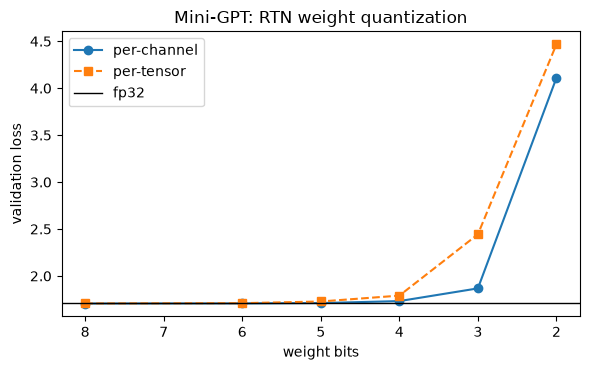

In [13]:
def quantize_model(model, bits, per_channel=True):
    m = copy.deepcopy(model)
    for mod in m.modules():
        if isinstance(mod, nn.Linear):
            q, s = quantize(mod.weight.data, bits, per_channel)
            mod.weight.data = dequantize(q, s)
    return m

base = val_loss(gpt)
bit_list = [8, 6, 5, 4, 3, 2]
res = {pc: [val_loss(quantize_model(gpt, b, pc)) for b in bit_list] for pc in (True, False)}
lin_params = sum(m.weight.numel() for m in gpt.modules() if isinstance(m, nn.Linear))
print(f"fp32 val loss {base:.3f}   (Linear weights: {lin_params/1e3:.0f}k params = {lin_params*4/1e6:.2f} MB in fp32)")
for i, b in enumerate(bit_list):
    print(f"{b} bits: per-channel {res[True][i]:.3f}   per-tensor {res[False][i]:.3f}   size {lin_params*b/8/1e6:.3f} MB")

plt.figure(figsize=(6, 3.8))
plt.plot(bit_list, res[True], "o-", label="per-channel")
plt.plot(bit_list, res[False], "s--", label="per-tensor")
plt.axhline(base, color="k", lw=1, label="fp32")
plt.gca().invert_xaxis()
plt.xlabel("weight bits"); plt.ylabel("validation loss"); plt.title("Mini-GPT: RTN weight quantization")
plt.legend(); plt.tight_layout(); plt.show()

- 8 down to 5 bits per-channel: the loss does not move (≤ 0.005).
- 4 bits: +0.02 per-channel, +0.08 to +0.1 per-tensor. 3 bits: +0.15 per-channel, +0.7 to +0.9 per-tensor.
- 2 bits (3 levels per row): both break, loss ≈ 3.9–4.5, about uniform guessing over 65 characters ($\ln 65 = 4.17$).

(Exact values shift by ~0.01 between runs: the mini-GPT trains on the GPU, which is not bit-reproducible.)

Per-channel scales matter more as the bit-width shrinks: with one scale for the whole tensor, rows with small weights get only a few of the $2^b-1$ levels.

✏️ **Group quantization** (one scale per group of 32 consecutive inputs in a row, as in GPTQ/AWQ checkpoints and NVFP4's per-16 scales): reshape `W` to `(d_out, d_in // 32, 32)`, quantize along the last dim, and redo the 3- and 2-bit rows. What does it cost in extra storage per weight (scale in fp16)?

## 6. Magnitude pruning: unstructured vs channels

**Unstructured**: per layer, zero the fraction $p$ of weights with the smallest $|w|$.
**Channel-level** (structured): zero whole output channels (conv filters, rows of a Linear) with the smallest $\ell_1$ norm $\sum|w|$. A zeroed channel can be removed, giving a smaller dense layer.
We keep a mask $M$ and use $W\odot M$.

In [14]:
def magnitude_mask(W, sparsity):
    k = int(round(sparsity * W.numel()))
    mask = torch.ones_like(W)
    if k > 0:
        idx = torch.topk(W.abs().flatten(), k, largest=False).indices
        mask.view(-1)[idx] = 0
    return mask

def channel_mask(W, sparsity):                 # W: (out, ...) conv filters or Linear rows
    n_prune = int(round(sparsity * W.shape[0]))
    mask = torch.ones_like(W)
    norms = W.abs().flatten(1).sum(1)
    mask[norms.argsort()[:n_prune]] = 0
    return mask

**Check** against `torch.nn.utils.prune` (`l1_unstructured` and `ln_structured` with $n=1$ along dim 0).

In [15]:
W = cnn.conv2.weight.detach()
for name, mine, lib in [("unstructured", magnitude_mask, lambda m, a: prune.l1_unstructured(m, "weight", amount=a)),
                        ("channel", channel_mask, lambda m, a: prune.ln_structured(m, "weight", amount=a, n=1, dim=0))]:
    tmp = copy.deepcopy(cnn.conv2); lib(tmp, 0.6)
    M = mine(W, 0.6)
    print(f"{name:12s}: masks differ at {(M != tmp.weight_mask).sum().item()} of {M.numel()} entries, sparsity {1 - M.mean().item():.2f}")

unstructured: masks differ at 0 of 18432 entries, sparsity 0.60
channel     : masks differ at 0 of 18432 entries, sparsity 0.59


sparsity              unstructured  unstructured + fine-tune                   channel       channel + fine-tune
  0.00                     0.875                     0.880                     0.875                     0.880
  0.30                     0.874                     0.885                     0.867                     0.879
  0.50                     0.874                     0.888                     0.837                     0.872
  0.70                     0.868                     0.887                     0.720                     0.845
  0.80                     0.869                     0.889                     0.535                     0.797
  0.90                     0.840                     0.892                     0.301                     0.665
  0.95                     0.762                     0.882                     0.185                     0.324
  0.98                     0.475                     0.838                     0.102                     0.142

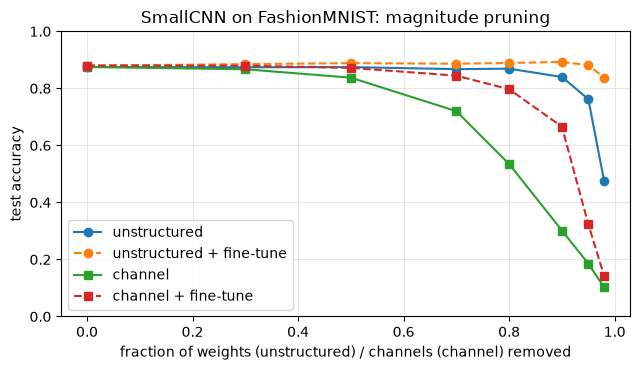

In [16]:
def pruned(model, sparsity, kind):
    m = copy.deepcopy(model)
    if kind == "unstructured":                 # global: one threshold over all weights, so each layer loses what it can spare
        layers = [m.conv1, m.conv2, m.fc1, m.fc2]
        flat = magnitude_mask(torch.cat([l.weight.data.flatten() for l in layers]), sparsity)
        masks = [M.view_as(l.weight) for M, l in zip(flat.split([l.weight.numel() for l in layers]), layers)]
    else:                                      # same fraction of channels in every hidden layer; never drop output classes
        layers = [m.conv1, m.conv2, m.fc1]
        masks = [channel_mask(l.weight.data, sparsity) for l in layers]
    def apply():
        with torch.no_grad():
            for l, M in zip(layers, masks):
                l.weight.mul_(M)
                if kind == "channel": l.bias.mul_(M.flatten(1)[:, 0])   # a removed channel has no bias either
    apply()
    return m, apply

sparsities = [0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.98]
acc = {}
for kind in ("unstructured", "channel"):
    acc[kind] = [accuracy(pruned(cnn, s, kind)[0]) for s in sparsities]
    acc[kind + " + fine-tune"] = []
    for s in sparsities:                       # + 1 epoch of fine-tuning with the mask re-applied after every step
        m, apply = pruned(cnn, s, kind)
        acc[kind + " + fine-tune"].append(accuracy(train(m, Xtr, ytr, epochs=1, lr=1e-3, after_step=apply)))
print("sparsity  " + "  ".join(f"{k:>24s}" for k in acc))
for i, s in enumerate(sparsities):
    print(f"  {s:.2f}  " + "  ".join(f"{v[i]:24.3f}" for v in acc.values()))

plt.figure(figsize=(6.5, 3.8))
for (k, v), st in zip(acc.items(), ["o-", "o--", "s-", "s--"]):
    plt.plot(sparsities, v, st, label=k)
plt.xlabel("fraction of weights (unstructured) / channels (channel) removed"); plt.ylabel("test accuracy"); plt.ylim(0, 1)
plt.title("SmallCNN on FashionMNIST: magnitude pruning"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

- **Unstructured** (global threshold): no retraining needed up to 80% sparsity (0.869 vs 0.875 dense), 0.84 at 90%. With one epoch of fine-tuning, 95% of the weights can go at no cost (0.882; the fine-tuned nets are slightly above the dense one because they got an extra epoch), and 98% still gives 0.84.
- **Channel**: hurts sooner (0.84 at 50%, 0.30 at 90% without retraining). Fine-tuning recovers 0.87 at 50% and 0.85 at 70%.
- The trade-off: removing 50% of the channels gives a dense network with about a quarter of the conv FLOPs (`conv2` loses both input and output channels), on any hardware. 95% unstructured sparsity only pays off with sparse kernels or 2:4 hardware support.

✏️ The masked model is not faster: it still multiplies by zeros. For 50% channel pruning, build a physically smaller `SmallCNN(c1=16, c2=32, hidden=64)` and copy the surviving filters into it (careful: `conv2` loses *input* channels too, and `fc1`'s inputs are `c2·7·7`). Check that its accuracy equals the masked model's.

## 7. Knowledge distillation

Teacher: the CNN above. Student: `SmallCNN(c1=8, c2=16, hidden=64)`, 8× fewer parameters. To make the soft labels matter we give the student only 1,000 labelled images (the teacher saw 10,000), and train it twice from the same init: with CE alone and with the distillation loss.

In [17]:
def kd_loss(s_logits, t_logits, y, T=4.0, alpha=0.9):
    log_p_t, log_p_s = F.log_softmax(t_logits / T, 1), F.log_softmax(s_logits / T, 1)
    kl = (log_p_t.exp() * (log_p_t - log_p_s)).sum(1).mean()
    return alpha * T * T * kl + (1 - alpha) * F.cross_entropy(s_logits, y)

s_, t_, y_ = torch.randn(32, 10), torch.randn(32, 10), torch.randint(0, 10, (32,))
ref = 0.9 * 16 * F.kl_div(F.log_softmax(s_ / 4, 1), F.log_softmax(t_ / 4, 1), reduction="batchmean", log_target=True) \
      + 0.1 * F.cross_entropy(s_, y_)
print(f"mine {kd_loss(s_, t_, y_).item():.6f}   torch {ref.item():.6f}   diff {abs(kd_loss(s_, t_, y_) - ref).item():.1e}")

mine 0.968553   torch 0.968553   diff 0.0e+00


In [18]:
Xs, ys = Xtr[:1000], ytr[:1000]
student_cfg = dict(c1=8, c2=16, hidden=64)
def kd_fn(logits, yb, xb, T=4.0):
    with torch.no_grad():
        t = cnn(xb)
    return kd_loss(logits, t, yb, T=T)

rows = []
for seed in range(3):
    torch.manual_seed(seed); init = SmallCNN(**student_cfg).to(device)
    alone = train(copy.deepcopy(init), Xs, ys, epochs=30, seed=seed)
    distilled = train(copy.deepcopy(init), Xs, ys, epochs=30, seed=seed, loss_fn=kd_fn)
    rows.append((accuracy(alone), accuracy(distilled)))
    print(f"seed {seed}: student alone {rows[-1][0]:.3f}   distilled {rows[-1][1]:.3f}")
r = np.array(rows)
print(f"teacher ({n_params(cnn)/1e3:.0f}k params) {accuracy(cnn):.3f} | student ({n_params(init)/1e3:.1f}k params): "
      f"alone {r[:,0].mean():.3f} ± {r[:,0].std():.3f}, distilled {r[:,1].mean():.3f} ± {r[:,1].std():.3f}")

seed 0: student alone 0.803   distilled 0.826


seed 1: student alone 0.813   distilled 0.825


seed 2: student alone 0.816   distilled 0.831
teacher (422k params) 0.875 | student (52.1k params): alone 0.811 ± 0.006, distilled 0.827 ± 0.002


Distillation adds 1.6 points (0.827 vs 0.811), several times the seed-to-seed spread, and wins in each of the three seeds; the student closes about a quarter of its gap to the teacher (0.875). The soft targets carry more information per image than the one-hot label (which classes look alike: shirt vs T-shirt vs pullover), which matters most when labelled images are few.

✏️ Run the distilled student with `T=1` and `T=10` (pass `T` through `kd_fn`). Then set `alpha=1` (no labels at all): how close does the student get using only the teacher's soft outputs on 1,000 images?

## 8. bf16 autocast, `torch.compile`, profiling

**bf16** keeps fp32's 8 exponent bits and cuts the mantissa to 7: same range, ~3 significant digits. Under `torch.autocast`, matmuls and convolutions run in bf16 while reductions (softmax, LayerNorm, losses) stay in fp32. On GPUs with tensor cores (A100, H100, and the T4's fp16) this is the default for training. **`torch.compile`** traces the model and fuses elementwise ops into larger kernels (fewer memory round-trips, fewer launches).

In [19]:
xb, yb = get_batch("val", 16, torch.Generator().manual_seed(0))
dev_type = xb.device.type
try:
    with torch.autocast(device_type=dev_type, dtype=torch.bfloat16):
        with torch.no_grad():
            logits_bf16 = gpt(xb)
    with torch.no_grad():
        logits_32 = gpt(xb)
    print("autocast output dtype:", logits_bf16.dtype)
    print(f"max |bf16 − fp32| logits = {(logits_bf16.float() - logits_32).abs().max().item():.3f}  "
          f"(logit scale {logits_32.abs().max().item():.1f});  loss fp32 {F.cross_entropy(logits_32.flatten(0,1), yb.flatten()).item():.4f}  "
          f"bf16 {F.cross_entropy(logits_bf16.float().flatten(0,1), yb.flatten()).item():.4f}")
    bf16_ok = True
except Exception as e:
    print("bf16 autocast not supported here:", type(e).__name__, str(e)[:100]); bf16_ok = False

autocast output dtype: torch.bfloat16
max |bf16 − fp32| logits = 0.078  (logit scale 14.7);  loss fp32 1.7072  bf16 1.7069


The logits move in the second or third digit, the loss in the third or fourth: that is bf16's precision, and it does not matter for training. Now timing, a forward pass over a batch of 16×256 tokens:

In [20]:
timings = {}
with torch.no_grad():
    timings["fp32"] = time_fn(lambda: gpt(xb), device)
    if bf16_ok:
        def f_bf16():
            with torch.autocast(device_type=dev_type, dtype=torch.bfloat16): return gpt(xb)
        timings["bf16 autocast"] = time_fn(f_bf16, device)
    try:
        t0 = time.time(); gpt_c = torch.compile(gpt); gpt_c(xb); compile_s = time.time() - t0
        print(f"max |compiled − eager| = {(gpt_c(xb) - gpt(xb)).abs().max().item():.1e}  (compile took {compile_s:.0f}s)")
        timings["torch.compile"] = time_fn(lambda: gpt_c(xb), device)
    except Exception as e:
        print("torch.compile not available here:", type(e).__name__, str(e).split("\n")[0][:100])
for k, v in timings.items():
    print(f"{k:14s} {v:7.1f} ms / forward  ({device})")

max |compiled − eager| = 8.3e-06  (compile took 13s)
fp32               4.2 ms / forward  (mps)
bf16 autocast      7.1 ms / forward  (mps)
torch.compile      5.0 ms / forward  (mps)


On a laptop GPU (MPS) with this small model, the three timings are within noise of each other or bf16 is slower (extra casts, no bf16 matrix units); `torch.compile` was faster in some runs, slower in others. The gains come with size and hardware: on a CUDA GPU with tensor cores and a GPT-2-sized model, bf16 autocast typically gives ~2× and `torch.compile` another 1.2–1.5× (both are measured step by step in Karpathy's GPT-2 video). ✏️ On Colab, set `n_embd=384, n_layer=6` and re-time.

**Profiling.** Before optimizing, find where the time goes. `torch.profiler` records every op of one training step (on a GPU add `ProfilerActivity.CUDA` and sort by `cuda_time_total`):

In [21]:
from torch.profiler import profile, ProfilerActivity
gpt_p = copy.deepcopy(gpt).to(bench).train()
xp, yp = xb.to(bench), yb.to(bench)
step = lambda: F.cross_entropy(gpt_p(xp).flatten(0, 1), yp.flatten()).backward()
step()                                         # warm-up
with profile(activities=[ProfilerActivity.CPU]) as prof:
    step()
ka = prof.key_averages()
print(ka.table(sort_by="self_cpu_time_total", row_limit=10, max_name_column_width=40))
mm_ops = ("aten::addmm", "aten::mm", "aten::bmm", "aten::_scaled_dot_product_flash_attention_for_cpu",
          "aten::_scaled_dot_product_flash_attention_for_cpu_backward")
total = sum(e.self_cpu_time_total for e in ka)
print(f"matmul + attention kernels: {sum(e.self_cpu_time_total for e in ka if e.key in mm_ops) / total:.0%} of the step; "
      f"everything else (elementwise, LayerNorm, copies, reductions): the rest")

----------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                    Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
----------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
aten::_scaled_dot_product_flash_atten...        11.93%      13.987ms        16.95%      19.868ms       6.623ms             3  
                                aten::mm         9.71%      11.386ms         9.72%      11.393ms     438.203us            26  
                              aten::add_         7.81%       9.160ms         7.81%       9.160ms     190.835us            48  
                     aten::gelu_backward         7.43%       8.709ms         7.43%       8.709ms       2.903ms             3  
                             aten::addmm         7.40%       8.672ms        13.09%      15.350ms       1.181ms 

USDT:2026-10-05 07:03:05 11307:16406780 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-10-05 07:03:05 11307:16406780 SyncActivityProfilerHandler.cpp:46] profiler_stop


The matmuls and attention are well under half of the step (about 25–40% across our runs); the rest is elementwise ops, LayerNorm, copies and reductions, each of which reads and writes whole activation tensors for very little arithmetic. These memory-bound ops are exactly what `torch.compile` fuses and what FlashAttention avoids materializing.

## 9. Why decoding is memory-bound

**Arithmetic intensity** $I$ = FLOPs per byte moved from memory. A device with peak compute $P$ (FLOP/s) and bandwidth $\beta$ (B/s) reaches at most
$$\text{FLOP/s} \le \min(P,\; \beta\cdot I)\qquad\text{(the roofline)},$$
so below the **ridge point** $I^* = P/\beta$ it waits for memory, above it for arithmetic.

One decoding step multiplies a batch of $B$ token vectors by every weight matrix. For one $d\times d$ fp32 matrix: $2Bd^2$ FLOPs; bytes $= 4(d^2 + 2Bd)$ (weights + input + output). For $B \ll d$, $I \approx B/2$: **one token per sequence per weight read**. At $B=1$ almost all time is spent reading weights, and a larger batch is free until $I$ reaches $I^*$.

First the effect on the mini-GPT: cached greedy decoding of 32 tokens for a batch of prompts on `device` (best of 5 runs).

In [22]:
gpt_b = copy.deepcopy(gpt).to(device)
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
tps = []
for bs in batch_sizes:
    prompts = get_batch("val", bs, torch.Generator().manual_seed(1))[0][:, :16].to(device)
    ms = time_fn(lambda: generate_cache(gpt_b, prompts, 32), device, reps=5)
    tps.append(bs * 32 / (ms / 1e3))
    print(f"batch {bs:4d}: {tps[-1]:9.0f} tokens/s   ({ms / 32:.2f} ms per step)")

batch    1:       432 tokens/s   (2.31 ms per step)


batch    2:       937 tokens/s   (2.14 ms per step)


batch    4:      1826 tokens/s   (2.19 ms per step)


batch    8:      3594 tokens/s   (2.23 ms per step)


batch   16:      6758 tokens/s   (2.37 ms per step)


batch   32:     13517 tokens/s   (2.37 ms per step)


batch   64:     28593 tokens/s   (2.24 ms per step)


batch  128:     58926 tokens/s   (2.17 ms per step)


Going from batch 1 to batch 128 multiplies the tokens per step by 128 while the time per step stays at a few ms (flat within noise on the MPS run): throughput rises ~100×. A model this small is not limited by DRAM bandwidth (its 1.4 MB of weights fit in cache) but by the fixed per-step cost of launching ~50 kernels; the consequence is the same as for a large model limited by reading its weights: one step's fixed cost is shared by every sequence in the batch.

To see the roofline itself, strip the model down to its core operation: one $4096\times4096$ fp32 weight matrix (64 MB, larger than any on-chip cache) times a batch of $B$ vectors. This runs on `device`: a GPU shows the roofline cleanly, while on a CPU the BLAS library switches kernels at small $B$ and blurs the picture.

In [23]:
def arithmetic_intensity(B, d, bytes_per=4):
    return 2 * B * d * d / (bytes_per * (d * d + 2 * B * d))

dm = 4096
Wbig = torch.randn(dm, dm, device=device)
Bs = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
gflops, ints = [], []
for Bq in Bs:
    xq = torch.randn(Bq, dm, device=device)
    ms = time_fn(lambda: xq @ Wbig, device, reps=50)
    gflops.append(2 * Bq * dm * dm / (ms / 1e3) / 1e9); ints.append(arithmetic_intensity(Bq, dm))
    print(f"B={Bq:4d}: {ms:7.2f} ms   I = {ints[-1]:6.1f} FLOP/B   {gflops[-1]:7.1f} GFLOP/s")
print("check: I(B=1) =", round(arithmetic_intensity(1, dm), 3), "(≈ 0.5)")

B=   1:    0.80 ms   I =    0.5 FLOP/B      42.1 GFLOP/s


B=   2:    1.02 ms   I =    1.0 FLOP/B      65.9 GFLOP/s


B=   4:    0.60 ms   I =    2.0 FLOP/B     224.8 GFLOP/s


B=   8:    1.05 ms   I =    4.0 FLOP/B     254.7 GFLOP/s
B=  16:    0.89 ms   I =    7.9 FLOP/B     604.7 GFLOP/s


B=  32:    1.25 ms   I =   15.8 FLOP/B     856.8 GFLOP/s
B=  64:    1.46 ms   I =   31.0 FLOP/B    1468.9 GFLOP/s


B= 128:    2.77 ms   I =   60.2 FLOP/B    1551.1 GFLOP/s


B= 256:    4.56 ms   I =  113.8 FLOP/B    1883.4 GFLOP/s


B= 512:    7.14 ms   I =  204.8 FLOP/B    2406.4 GFLOP/s
check: I(B=1) = 0.5 (≈ 0.5)


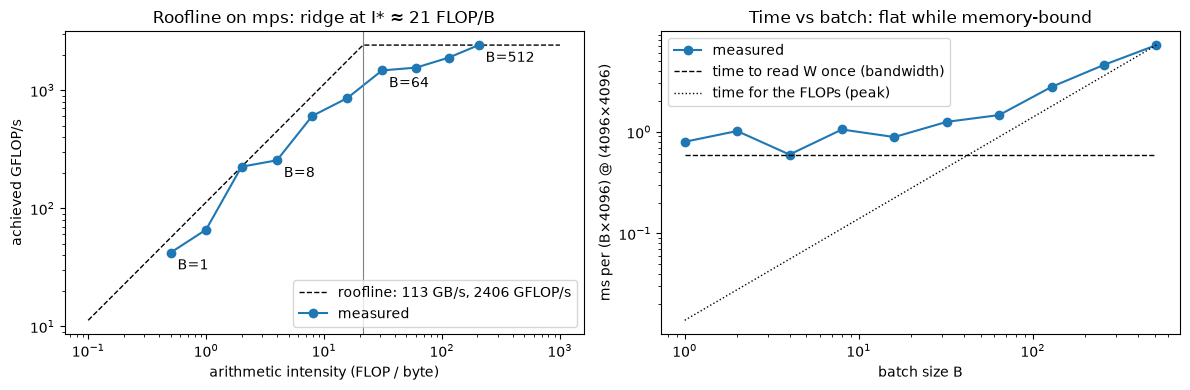

In [24]:
bw = max(g / i for g, i, Bq in zip(gflops, ints, Bs) if Bq <= 16)   # GB/s achieved while streaming weights (small B)
peak = max(gflops)
ridge = peak / bw
ms_list = [2 * Bq * dm * dm / (g * 1e9) * 1e3 for Bq, g in zip(Bs, gflops)]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
I_line = np.logspace(-1, 3, 200)
ax[0].loglog(I_line, np.minimum(peak, bw * I_line), "k--", lw=1, label=f"roofline: {bw:.0f} GB/s, {peak:.0f} GFLOP/s")
ax[0].loglog(ints, gflops, "o-", label="measured")
for Bq, i, g in zip(Bs, ints, gflops):
    if Bq in (1, 8, 64, 512): ax[0].annotate(f"B={Bq}", (i, g), textcoords="offset points", xytext=(5, -12))
ax[0].axvline(ridge, color="gray", lw=0.8)
ax[0].set(xlabel="arithmetic intensity (FLOP / byte)", ylabel="achieved GFLOP/s", title=f"Roofline on {device}: ridge at I* ≈ {ridge:.0f} FLOP/B")
ax[0].legend(loc="lower right")
B_line = np.logspace(0, np.log10(512), 100)
ax[1].loglog(Bs, ms_list, "o-", label="measured")
ax[1].loglog(B_line, [4 * dm * dm / (bw * 1e9) * 1e3] * len(B_line), "k--", lw=1, label="time to read W once (bandwidth)")
ax[1].loglog(B_line, 2 * B_line * dm * dm / (peak * 1e9) * 1e3, "k:", lw=1, label="time for the FLOPs (peak)")
ax[1].set(xlabel="batch size B", ylabel="ms per (B×4096) @ (4096×4096)", title="Time vs batch: flat while memory-bound")
ax[1].legend(); plt.tight_layout(); plt.show()

- Left: at small $B$ the measured points follow the slanted (bandwidth) line, at large $B$ they reach the flat (compute) line. The ridge of this laptop GPU is ~10–20 FLOP/B; a data-center GPU's is much higher (below).
- Right: up to $B\approx 64$ the time stays near the time to read the 64 MB of weights once (dashed line), then grows linearly with $B$ once the FLOPs dominate (dotted line). In between, nothing is gained by computing less: a $B=16$ product costs about as much as a $B=1$ product.
- Individual points jump around (other processes share the GPU, and the library switches kernels with $B$); read the trend.

**The same estimate for a real model.** Llama-2-7B in bf16 is 13.5 GB. An H100 has $\beta\approx3.35$ TB/s and $P\approx990$ TFLOP/s (dense bf16), so $I^*\approx300$ FLOP/B; with 2-byte weights, $I\approx B$.
- At $B=1$: at most $3.35\,\text{TB/s} / 13.5\,\text{GB} \approx 250$ tokens/s, using about $0.3\%$ of the compute.
- The batch must reach ~300 sequences before compute is the limit (in practice the KV cache, which is read per sequence, often runs out of memory first).

This one inequality explains the serving tricks from the lecture: **weight-only int4** quarters the bytes, so ~4× tokens/s at $B=1$ (and why W4A16 beats W8A8 for single-user decoding); **speculative decoding** verifies $k$ tokens per weight read; **batching / PagedAttention** raises $B$; **FlashAttention** raises the intensity of attention itself by keeping tiles on-chip.

✏️ Redo the 7B estimate for int4 weights on a T4 ($\beta\approx 320$ GB/s). Then for a 70B model on 8×H100 with the weights split across GPUs.

## 10. If time: speculative decoding with a 4-bit draft

Greedy speculative decoding: the draft proposes $k$ tokens one by one (cheap); the target runs all of them in **one** cached forward pass and keeps the longest prefix on which its own argmax agrees, plus its own next token. The output equals the target's greedy output exactly. Here the draft is the int4 copy of the mini-GPT (self-speculation with a quantized draft). It is as large as the target, so there is no wall-clock gain on this model; what we measure is how many target passes are saved.

In [25]:
def crop(cache, n):
    for c in cache:
        if c: c[:] = [c[0][:, :, :n], c[1][:, :, :n]]

@torch.no_grad()
def speculative_greedy(target, draft, idx, n_new, k=4):
    seq = idx[0].tolist()
    tc, dc = new_cache(target), new_cache(draft)
    forward_cached(target, idx[:, :-1], tc); forward_cached(draft, idx[:, :-1], dc)   # caches hold all but the last token
    target_calls, accepted = 0, []
    total = idx.shape[1] + n_new
    while len(seq) < total:
        k_now = min(k, total - len(seq))       # do not run past the last position
        # 1) draft proposes k tokens greedily
        d_len = dc[0][0].shape[2]
        logits = forward_cached(draft, torch.tensor([seq[d_len:]], device=idx.device), dc)[:, -1]
        prop = []
        for i in range(k_now):
            prop.append(logits.argmax(-1).item())
            if i < k_now - 1: logits = forward_cached(draft, torch.tensor([[prop[-1]]], device=idx.device), dc)[:, -1]
        # 2) target scores [last token, proposals] in one pass
        L = tc[0][0].shape[2]
        t_pred = forward_cached(target, torch.tensor([[seq[-1]] + prop], device=idx.device), tc)[0].argmax(-1).tolist()
        target_calls += 1
        n_ok = 0
        while n_ok < k_now and prop[n_ok] == t_pred[n_ok]: n_ok += 1
        seq += prop[:n_ok] + [t_pred[n_ok]]
        accepted.append(n_ok)
        crop(tc, L + 1 + n_ok); crop(dc, min(dc[0][0].shape[2], len(seq) - 1))           # roll back rejected positions
    return torch.tensor([seq[:total]]), target_calls, accepted

n_spec = n_new
draft = quantize_model(gpt, 4)
ref_out = generate_cache(gpt, prompt, n_spec)
for name, dr in [("int4 draft", draft), ("int2 draft", quantize_model(gpt, 2))]:
    out, calls, acc = speculative_greedy(gpt, dr, prompt, n_spec, k=4)
    print(f"{name}: identical to target greedy: {torch.equal(out.to(device), ref_out)}   "
          f"target passes {calls} for {n_spec} tokens ({n_spec / calls:.2f} tokens/pass), mean accepted {np.mean(acc):.2f} of 4")

int4 draft: identical to target greedy: True   target passes 30 for 121 tokens (4.03 tokens/pass), mean accepted 3.07 of 4


int2 draft: identical to target greedy: True   target passes 103 for 121 tokens (1.17 tokens/pass), mean accepted 0.17 of 4


Both drafts reproduce the target's greedy output exactly, as they must. The int4 draft agrees with the target on 2–3 of 4 proposals on average (3.1 in the run shown) (the exact number varies between runs, since GPU training is not bit-reproducible and the draft is a slightly different model each time), so the target runs 30–40 times for 121 tokens, 3–4 tokens per read of its weights. The int2 draft (loss ≈ 4 in section 5) is almost always rejected (≈ 0.1–0.2 of 4 accepted). A useful draft must be both much cheaper than the target and close to it.

✏️ Train a 1-layer `MiniGPT(vocab, n_embd=48, n_layer=1)` for 300 steps and use it as the draft. Its acceptance will be lower, but each draft step is now much cheaper: estimate the speed-up with cost(draft) ≈ (draft params / target params) × cost(target).

## Summary
- **Accounting**: parameters $\approx 12Ld^2$ + embeddings; $2N$ FLOPs/token forward, $6N$ training, plus $4LTd$ for attention; 16 bytes/param for weights + grads + Adam in fp32 or mixed precision. Measured FLOP/s divided by peak (MFU) tells how much of the hardware is doing model math.
- **KV cache**: same tokens as recomputing the prefix, linear instead of quadratic work; the price is $2\,n_{\text{layers}}\,T\,d$ values of memory per sequence.
- **Quantization**: symmetric per-channel RTN is a few lines; 8-bit weights are free, 4-bit costs little, 2-bit breaks the model without GPTQ/AWQ-style error compensation or QAT. Per-channel scales matter most at low bit-widths.
- **Pruning**: unstructured magnitude pruning removes most weights of an over-parameterized net before accuracy moves; channel pruning hurts sooner but yields a genuinely smaller dense model, and a short fine-tune recovers much of the loss.
- **Distillation**: soft targets at temperature $T$, scaled by $T^2$, transfer the teacher's knowledge about class similarity; it helps most when labelled data is scarce.
- **Decoding is memory-bound**: at batch 1 each weight byte serves ~1 FLOP, so tokens/s is set by bandwidth / model bytes. Batching, int4 weights and speculative decoding all raise the work done per byte read.

**Further reading:** Stanford CS336 (Language Modeling from Scratch), lecture 2 *Resource accounting* (section 3 follows it), https://cs336.stanford.edu ; Stanford CME 295 (Fall 2025), lecture 4 slides (quantization, hardware optimization), https://cme295.stanford.edu/slides/fall25-cme295-lecture4.pdf .

**Further watching:** Song Han, *Efficient Methods and Hardware for Deep Learning* (CS231n 2017, Lecture 15), https://www.youtube.com/watch?v=eZdOkDtYMoo ; MIT 6.5940 *TinyML and Efficient Deep Learning Computing* (the source of the lecture slides), https://efficientml.ai ; Karpathy, *Let's reproduce GPT-2 (124M)* (bf16, `torch.compile`, FlashAttention in practice), https://www.youtube.com/watch?v=l8pRSuU81PU .